# 6 · Lab: Heralded Fock-State Preparation

**Simulation lab, part 2 · Wednesday July 29, 11:30–12:30 · small groups**

Monday you *described* Fock states, Tuesday you learned to *certify* them — today you **make** them, the way most labs actually do: **spontaneous parametric down-conversion (SPDC) + heralding.** And you will run into the same enemy every lab does: loss and multi-pair emission.

### Learning objectives

1. simulate a two-mode SPDC-like source and herald Fock states from it,
2. characterize a heralded state via $P(n)$ and $g^{(2)}(0)$,
3. optimize a heralded single-photon source under loss with a quantitative figure of merit.

*Key papers: [Branczyk2010] (theory of exactly this lab), [Cooper2013] (the real experiment, $n$ up to 3), [MeyerScott2020] (review) — in [`references.bib`](../references.bib).*

In [1]:
# Install packages if missing (needed on Google Colab; no-op in Codespaces).
import importlib.util, subprocess, sys
if importlib.util.find_spec("perceval") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet",
                           "perceval-quandela"])

from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import perceval as pcvl
from perceval.simulators import Simulator
from perceval.backends import SLOSBackend

plt.rcParams.update({"figure.figsize": (6, 4), "font.size": 12,
                     "axes.grid": True, "grid.alpha": 0.3})
print("perceval", pcvl.__version__)

perceval 1.2.4


## 6.1 · The source: two-mode squeezed vacuum

SPDC in a nonlinear crystal converts one pump photon into a **pair**: a *signal* photon and an *idler* photon. Because pairs are always created together, the output state (for one signal mode and one idler mode) is the **two-mode squeezed vacuum**:

$$|\psi\rangle \;=\; \sqrt{1-\lambda^2}\,\sum_{n=0}^{\infty} \lambda^n \,|n\rangle_s |n\rangle_i ,$$

where $\lambda \in [0,1)$ grows with pump power. Perfect photon-number correlation between the arms — that is the resource. Note what it implies:

* look at **both** arms: detecting $n$ idler photons *projects* the signal onto exactly $|n\rangle$ → **heralded Fock states**;
* look at **one** arm only: tracing out the idler leaves a **thermal** state with $\bar n = \lambda^2/(1-\lambda^2)$ (Tuesday's quiz question 2 — here is the punchline).

In Perceval we build this state directly as a `StateVector` (truncating the sum — check convergence!):

In [2]:
N_MAX = 6   # truncation: keep terms up to |N_MAX, N_MAX> (lambda^6 is tiny)

def tmsv(lam: float, n_extra_modes: int = 0) -> pcvl.StateVector:
    """Two-mode squeezed vacuum sum_n lambda^n |n,n>, truncated at N_MAX.

    Parameters
    ----------
    lam : squeezing parameter lambda in [0, 1) (dimensionless)
    n_extra_modes : number of extra empty modes appended (for loss ancillas)

    Perceval normalizes StateVectors automatically.
    """
    lam = float(lam)   # plain float: numpy scalars confuse StateVector algebra
    sv = pcvl.StateVector()
    for n in range(N_MAX + 1):
        sv += (lam ** n) * pcvl.StateVector(
            pcvl.BasicState([n, n] + [0] * n_extra_modes))
    return sv

# Sanity check: photon-number distribution of the source at lambda = 0.4
lam = 0.4
sim = Simulator(SLOSBackend())
sim.set_circuit(pcvl.Circuit(2))          # empty circuit: just look at the state
dist = sim.probs(tmsv(lam))

print("P(n_signal, n_idler):")
for st, p in sorted(dist.items(), key=lambda kv: -kv[1]):
    if p > 1e-4:
        print(f"  {st}: {p:.4f}")
print("\nonly diagonal terms |n,n> - perfect pair correlation")

P(n_signal, n_idler):
  |0,0>: 0.8400
  |1,1>: 0.1344
  |2,2>: 0.0215
  |3,3>: 0.0034
  |4,4>: 0.0006

only diagonal terms |n,n> - perfect pair correlation


## 6.2 · Worked example: heralding an ideal single photon

Put a **photon-number-resolving detector** in the idler arm. Keep only the runs where it fires with exactly 1 photon. What is the signal state on those runs?

In [3]:
def heralded_signal_distribution(dist, idler_mode: int = 1,
                                 herald_condition=lambda n: n == 1):
    """Signal photon-number distribution conditioned on an idler outcome.

    Parameters
    ----------
    dist : Perceval probability distribution over BasicStates
    idler_mode : index of the mode carrying the herald detector
    herald_condition : function n_idler -> bool defining the herald

    Returns
    -------
    P_heralded : dict n_signal -> conditional probability
    P_herald : total probability that the herald fires (the source "brightness")
    """
    joint = defaultdict(float)
    for st, p in dist.items():
        if herald_condition(st[idler_mode]):
            joint[st[0]] += p
    P_herald = sum(joint.values())
    return {n: p / P_herald for n, p in sorted(joint.items())}, P_herald


def g2_from_distribution(P: dict) -> float:
    """g2(0) = <n(n-1)>/<n>^2 from a photon-number distribution dict."""
    mean = sum(n * p for n, p in P.items())
    pairs = sum(n * (n - 1) * p for n, p in P.items())
    return pairs / mean ** 2


P_h, brightness = heralded_signal_distribution(dist)
print(f"lambda = {lam}, ideal PNR herald on n_idler = 1:")
print(f"  P(herald fires) = {brightness:.4f}")
print(f"  P(n_signal | herald) = {P_h}")
print(f"  heralded g2(0) = {g2_from_distribution(P_h):.4f}")

lambda = 0.4, ideal PNR herald on n_idler = 1:
  P(herald fires) = 0.1344
  P(n_signal | herald) = {1: 1.0}
  heralded g2(0) = 0.0000


A **perfect** single photon: $P(1|{\rm herald}) = 1$, $g^{(2)}(0) = 0$. Too good to be true — and indeed it is, twice over:

1. real idler detectors miss photons (**loss**): a 2-pair event where one idler photon is lost looks *exactly* like a 1-pair event → the "single photon" is secretly $|2\rangle$ sometimes;
2. most real detectors are **click detectors** (SPAD/SNSPD without multiplexing): they say "≥ 1 photon", not "exactly 1".

## 6.3 · Loss = a beamsplitter to a mode nobody watches

The standard trick (you met it Monday as binomial thinning): transmission $\eta$ is a beamsplitter with reflectivity $1-\eta$ routing photons into an extra *loss mode* that is traced over. Let's add an idler loss mode:

```
mode 0: signal ────────────────────
mode 1: idler ────BS(η_i)────────── PNR/click herald
mode 2: (loss)       └────────────  nobody looks here
```

In [4]:
def spdc_with_idler_loss(lam: float, eta_idler: float):
    """Joint output distribution of a TMSV with idler transmission eta_idler.

    Mode layout: 0 = signal, 1 = idler (detected), 2 = idler loss mode.
    """
    circuit = pcvl.Circuit(3)
    # reflectivity = eta: probability eta that the idler photon STAYS in mode 1
    circuit.add((1, 2), pcvl.BS(theta=pcvl.BS.r_to_theta(eta_idler)))
    sim = Simulator(SLOSBackend())
    sim.set_circuit(circuit)
    return sim.probs(tmsv(lam, n_extra_modes=1))


def marginal_over_loss(dist):
    """Sum probabilities over the unobserved loss mode (mode 2)."""
    out = defaultdict(float)
    for st, p in dist.items():
        out[(st[0], st[1])] += p   # keep (signal, detected idler) only
    return out


# Heralded state with a lossy PNR idler detector, eta = 0.6:
dist3 = marginal_over_loss(spdc_with_idler_loss(lam=0.4, eta_idler=0.6))
joint = defaultdict(float)
for (n_s, n_i), p in dist3.items():
    if n_i == 1:                       # PNR herald: exactly one idler DETECTED
        joint[n_s] += p
brightness = sum(joint.values())
P_h = {n: p / brightness for n, p in sorted(joint.items())}

print(f"lambda = 0.4, eta_idler = 0.6, PNR herald on 1 detected photon:")
print(f"  P(herald) = {brightness:.4f}")
for n, p in P_h.items():
    print(f"  P(n_signal = {n} | herald) = {p:.4f}")
print(f"  heralded g2(0) = {g2_from_distribution(P_h):.4f}")

lambda = 0.4, eta_idler = 0.6, PNR herald on 1 detected photon:
  P(herald) = 0.0920
  P(n_signal = 1 | herald) = 0.8761
  P(n_signal = 2 | herald) = 0.1121
  P(n_signal = 3 | herald) = 0.0108
  P(n_signal = 4 | herald) = 0.0009
  P(n_signal = 5 | herald) = 0.0001
  P(n_signal = 6 | herald) = 0.0000
  heralded g2(0) = 0.2334


There it is: the herald *fired on exactly one photon*, yet the signal contains $|2\rangle$ (and worse) with several percent probability — the partner of the lost idler photon. The heralded $g^{(2)}(0)$ is no longer 0.

## 6.4 · The design challenge (25 min, small groups)

You are building a heralded single-photon source for a quantum network. Fixed hardware:

* idler transmission $\eta_i = 0.6$ (fiber + detector),
* the herald detector is a **click detector**: it fires for *any* $n_{\rm detected} \ge 1$,
* your only knob is the **pump power**, i.e. $\lambda \in (0, 0.9)$.

The trade-off you must quantify: cranking $\lambda$ up gives more heralds (brightness ↑) but more multi-pair contamination (purity ↓). Define

$$\text{FOM}(\lambda) = \underbrace{P(\text{herald fires})}_{\text{brightness } B} \times \underbrace{P(n_s = 1 \mid \text{herald})}_{\text{single-photon purity } \Pi}$$

**Tasks:**
1. implement the click-detector herald ($n_i \ge 1$ detected),
2. plot $B(\lambda)$, $\Pi(\lambda)$, and FOM($\lambda$) for $\lambda \in [0.05, 0.9]$,
3. report: your optimal $\lambda$, and the heralded $g^{(2)}(0)$ at that operating point — does your optimized source still pass the $g^{(2)}(0) < 0.5$ certificate from yesterday?
4. **group competition:** highest FOM *subject to* heralded $g^{(2)}(0) < 0.1$ wins. (You may now also assume a better detector, $\eta_i$ up to 0.95 — money buys performance. Does the optimal $\lambda$ move up or down?)

In [5]:
# YOUR CODE HERE - design challenge
lambdas = np.linspace(0.05, 0.9, 18)


## 6.5 · Worked finale: heralding $|2\rangle$

With a PNR herald (a TES, or a multiplexed SNSPD) you can post-select $n_i = 2$ and prepare **two-photon Fock states** — exactly what [Cooper2013] did in the lab up to $n = 3$. The fingerprint of $|2\rangle$: $g^{(2)}(0) = 1 - 1/2 = 0.5$ (Monday's formula).

In [6]:
# Herald on exactly 2 detected idler photons (ideal PNR, no loss for clarity).
sim = Simulator(SLOSBackend())
sim.set_circuit(pcvl.Circuit(2))
dist = sim.probs(tmsv(0.5))

P_h2, brightness2 = heralded_signal_distribution(
    dist, herald_condition=lambda n: n == 2)
print(f"PNR herald on n_idler = 2 (lambda = 0.5):")
print(f"  P(herald) = {brightness2:.4f}")
print(f"  P(n_signal | herald) = {P_h2}")
print(f"  heralded g2(0) = {g2_from_distribution(P_h2):.3f}   (theory: 0.5)")

PNR herald on n_idler = 2 (lambda = 0.5):
  P(herald) = 0.0469
  P(n_signal | herald) = {2: 1.0}
  heralded g2(0) = 0.500   (theory: 0.5)


## 6.6 · Wrap-up: you now own the toolbox

Three days, one coherent story:

| day | concept | tool |
|---|---|---|
| Mon | photon statistics $P(n)$, Mandel $Q$ | QuTiP |
| Tue | correlations $g^{(2)}$, HBT, sources & detectors | time-tag analysis |
| Wed | HOM interference · heralded Fock states | Perceval |

These are precisely the primitives of **photonic quantum computing**: heralded sources (today), interference in programmable interferometers (this morning), photon-number-resolving detection (Tuesday). Scale it up and you get boson sampling [Zhong2020] and measurement-based photonic quantum computers — the machines Perceval was built to program [Heurtel2023].

**Where to go from here**

* *Books:* Fox [Fox2006] (accessible), Gerry & Knight [GerryKnight2005] (thorough), Loudon [Loudon2000] (the classic).
* *Reviews:* [Bouchard2021] (HOM), [MeyerScott2020] (sources), [Natarajan2012] (detectors).
* *Play:* the [Perceval documentation](https://perceval.quandela.net/docs/) has tutorials from HOM to full boson sampling — everything you built today scales.

## Hand in your work

```bash
mkdir -p submissions/<your-github-username>
cp lectures/05_Lab_HOM_Interference.ipynb lectures/06_Lab_HeraldedFockStates.ipynb \
   submissions/<your-github-username>/
git add submissions/ && git commit -m "Wednesday labs" && git push
```

Open a Pull Request with your best FOM in the description — winners announced at the discussion session. **Obrigado & keep counting photons!**

---
---

# Sample solutions

**No peeking during the session.**

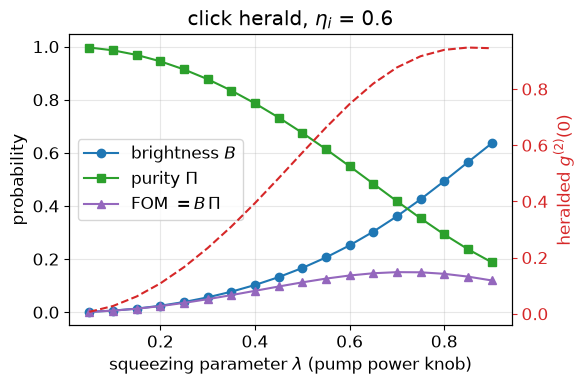

optimal lambda = 0.70: FOM = 0.151, heralded g2(0) = 0.877
best FOM with g2 < 0.1 constraint: lambda = 0.15, FOM = 0.013, g2(0) = 0.062


In [7]:
# Solution - design challenge
def click_herald_source(lam: float, eta_idler: float):
    """Brightness, purity, and heralded g2(0) for a click-detector herald.

    Returns (B, purity, g2_heralded).
    """
    dist = marginal_over_loss(spdc_with_idler_loss(lam, eta_idler))
    joint = defaultdict(float)
    for (n_s, n_i), p in dist.items():
        if n_i >= 1:                   # click detector: any detected photon
            joint[n_s] += p
    B = sum(joint.values())
    P_h = {n: p / B for n, p in joint.items()}
    return B, P_h.get(1, 0.0), g2_from_distribution(P_h)


lambdas = np.linspace(0.05, 0.9, 18)
eta_i = 0.6
results = np.array([click_herald_source(lam, eta_i) for lam in lambdas])
B, purity, g2_h = results.T
fom = B * purity

fig, ax1 = plt.subplots()
ax1.plot(lambdas, B, "o-", color="tab:blue", label="brightness $B$")
ax1.plot(lambdas, purity, "s-", color="tab:green", label=r"purity $\Pi$")
ax1.plot(lambdas, fom, "^-", color="tab:purple", label=r"FOM $= B\,\Pi$")
ax1.set_xlabel(r"squeezing parameter $\lambda$ (pump power knob)")
ax1.set_ylabel("probability")
ax1.legend(loc="center left")
ax2 = ax1.twinx()
ax2.plot(lambdas, g2_h, "--", color="tab:red")
ax2.set_ylabel(r"heralded $g^{(2)}(0)$", color="tab:red")
ax2.tick_params(axis="y", colors="tab:red")
ax2.grid(False)
plt.title(f"click herald, $\\eta_i$ = {eta_i}")
plt.tight_layout(); plt.show()

best = np.argmax(fom)
print(f"optimal lambda = {lambdas[best]:.2f}: "
      f"FOM = {fom[best]:.3f}, heralded g2(0) = {g2_h[best]:.3f}")
ok = g2_h < 0.1
if ok.any():
    best_c = np.where(ok, fom, 0).argmax()
    print(f"best FOM with g2 < 0.1 constraint: lambda = {lambdas[best_c]:.2f}, "
          f"FOM = {fom[best_c]:.3f}, g2(0) = {g2_h[best_c]:.3f}")
# With a better detector (eta_i -> 0.95) the g2 penalty per lambda shrinks,
# so the constrained optimum moves to HIGHER lambda: better detectors let
# you pump harder. Efficiency is everything - again.